# TP3

In [1]:
corpus = [
    "Cats are smarter than dogs.",
    "Dogs are more loyal than cats.",
    "Cats and dogs can be good pets."
]


### Bag-of-Words (BoW) avec CountVectorizer

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus)

# Affichage
print("Mots (features) :", vectorizer.get_feature_names_out())
print("Matrice BoW :\n", bow_matrix.toarray())


Mots (features) : ['and' 'are' 'be' 'can' 'cats' 'dogs' 'good' 'loyal' 'more' 'pets'
 'smarter' 'than']
Matrice BoW :
 [[0 1 0 0 1 1 0 0 0 0 1 1]
 [0 1 0 0 1 1 0 1 1 0 0 1]
 [1 0 1 1 1 1 1 0 0 1 0 0]]


###  TF-IDF avec TfidfVectorizer

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# Affichage
print("Mots (features) :", tfidf_vectorizer.get_feature_names_out())
print("Matrice TF-IDF :\n", tfidf_matrix.toarray())


Mots (features) : ['and' 'are' 'be' 'can' 'cats' 'dogs' 'good' 'loyal' 'more' 'pets'
 'smarter' 'than']
Matrice TF-IDF :
 [[0.         0.45014501 0.         0.         0.34957775 0.34957775
  0.         0.         0.         0.         0.59188659 0.45014501]
 [0.         0.38737583 0.         0.         0.30083189 0.30083189
  0.         0.50935267 0.50935267 0.         0.         0.38737583]
 [0.4189401  0.         0.4189401  0.4189401  0.24743277 0.24743277
  0.4189401  0.         0.         0.4189401  0.         0.        ]]


### Comparaison BoW vs TF-IDF
BoW : les mots fréquents ont plus de poids.

TF-IDF : les mots fréquents mais peu informatifs (ex : "are", "and") sont atténués.

### Word2Vec avec Gensim

In [4]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

tokenized_corpus = [word_tokenize(sent.lower()) for sent in corpus]
model = Word2Vec(sentences=tokenized_corpus, vector_size=50, window=2, min_count=1)


In [5]:
print("Similaires à 'cats' :", model.wv.most_similar("cats"))
print("Similarité cats/dogs :", model.wv.similarity("cats", "dogs"))


Similaires à 'cats' : [('are', 0.1656268686056137), ('more', 0.15523763000965118), ('can', 0.1394219845533371), ('.', 0.12669861316680908), ('loyal', 0.12127130478620529), ('good', 0.08874192088842392), ('dogs', 0.011053049005568027), ('pets', -0.027847401797771454), ('smarter', -0.03341139853000641), ('and', -0.03728298097848892)]
Similarité cats/dogs : 0.011053048


###  Comparaison des techniques
Similarité cosinus (BoW + TF-IDF + Word2Vec)

Cosine avec TF-IDF :

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

sim_tfidf = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])
print("Similarité TF-IDF phrase 0 vs 1 :", sim_tfidf[0][0])


Similarité TF-IDF phrase 0 vs 1 : 0.55907886566406


Cosine avec BoW :

In [7]:
sim_bow = cosine_similarity(bow_matrix[0], bow_matrix[1])
print("Similarité BoW phrase 0 vs 1 :", sim_bow[0][0])


Similarité BoW phrase 0 vs 1 : 0.7302967433402215


### Cosine entre mots (Word2Vec)

In [8]:
print("Similarité 'cats' et 'dogs' Word2Vec :", model.wv.similarity("cats", "dogs"))


Similarité 'cats' et 'dogs' Word2Vec : 0.011053048


#### Visualisation des Word Embeddings avec t-SNE

In [9]:
import numpy as np

# Sélection des 10 mots les plus fréquents (ou tous si petit corpus)
words = list(model.wv.index_to_key)[:10]
vectors = np.array([model.wv[word] for word in words])


In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(vectors)


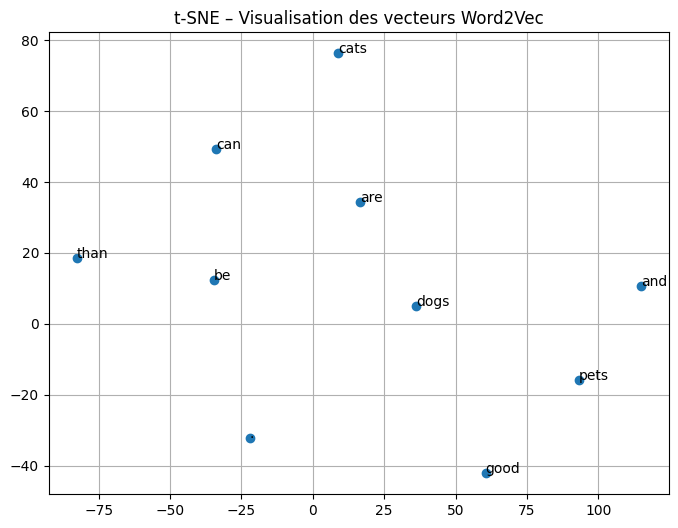

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.title("t-SNE – Visualisation des vecteurs Word2Vec")
plt.grid(True)
plt.show()


 les mots similaires comme "cats", "dogs", "pets" groupés visuellement, selon leur proximité dans l’espace vectoriel appris par Word2Vec.